# Análisis Exploratorio de Datos (EDA) - Proyecto Salva Health MLOps
**Autor:** Valentin Moreno Vasquez 

**Objetivo:** Evaluar la calidad de los datos biométricos de los pacientes y entender las características clave asociadas con anomalías cardíacas antes de entrenar los modelos productivos.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys
from pathlib import Path
ROOT_DIR = Path.cwd().parent
sys.path.append(str(ROOT_DIR))
from src.utils.config import RAW_DATA_PATH

In [3]:
# Carga del dataset original
df = pd.read_csv(RAW_DATA_PATH / "pacientes.csv")

print(f"Dimensiones del dataset: {df.shape[0]} filas y {df.shape[1]} columnas.\n")
print(" Primeros 5 registros ")
display(df.head())

Dimensiones del dataset: 515 filas y 10 columnas.

 Primeros 5 registros 


,id_paciente,edad_paciente,sexo,peso_kg,altura_cm,fecha_registro,frecuencia_cardiaca_media_bpm,derivacion_ecg,frecuencia_muestreo_hz,etiqueta
0,P0305,82.0,M,69.8,168.0,2023-10-04,69.4,II,250,Normal
1,P0500,58.0,M,70.9,178.9,2023-04-23,79.2,II,250,Normal
2,P0442,49.0,M,84.2,173.1,2023-01-25,72.7,II,250,Normal
3,P0154,39.0,F,80.5,156.4,2023-06-24,87.0,II,250,Anormal
4,P0479,22.0,F,78.7,165.5,2023-01-28,77.8,II,250,Normal


## 1. Calidad de Datos e Identificación de Problemas
En esta sección evaluamos la presencia de valores nulos, la consistencia de los tipos de datos y la detección de registros anómalos o ruido introducido por error humano.

In [4]:
print("Información de tipos de datos y nulos")
df.info()

print("\n Conteo total de valores nulos por columna")
print(df.isnull().sum())

Información de tipos de datos y nulos
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515 entries, 0 to 514
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   id_paciente                    515 non-null    object 
 1   edad_paciente                  511 non-null    float64
 2   sexo                           511 non-null    object 
 3   peso_kg                        509 non-null    float64
 4   altura_cm                      509 non-null    float64
 5   fecha_registro                 515 non-null    object 
 6   frecuencia_cardiaca_media_bpm  515 non-null    float64
 7   derivacion_ecg                 515 non-null    object 
 8   frecuencia_muestreo_hz         515 non-null    int64  
 9   etiqueta                       515 non-null    object 
dtypes: float64(4), int64(1), object(5)
memory usage: 40.4+ KB

 Conteo total de valores nulos por columna
id_paciente                   

In [5]:
# Investigando los valores mínimos y máximos extraños detectados en la edad
edades_aberrantes = df[(df['edad_paciente'] < 0) | (df['edad_paciente'] > 100)]
print(f"Se detectaron {len(edades_aberrantes)} registros con edades biológicamente imposibles o erróneas:")
display(edades_aberrantes)

Se detectaron 6 registros con edades biológicamente imposibles o erróneas:


,id_paciente,edad_paciente,sexo,peso_kg,altura_cm,fecha_registro,frecuencia_cardiaca_media_bpm,derivacion_ecg,frecuencia_muestreo_hz,etiqueta
24,P0125,150.0,F,62.0,156.8,2023-11-04,72.1,II,250,Normal
135,P0043,140.0,NaN,80.8,169.8,2023-04-17,78.7,II,250,Normal
221,P0200,132.0,F,69.2,164.8,2023-10-30,49.1,II,250,Normal
249,P0090,-3.0,M,80.6,178.1,2023-06-05,77.5,II,250,Normal
262,P0147,-1.0,M,81.1,174.4,2023-06-14,100.1,II,250,Anormal
369,P0435,-5.0,F,48.1,158.4,18/05/2023,79.3,II,250,Anormal


## 2. Análisis del Target y Variables Categóricas
Evaluamos si la variable predictiva (`etiqueta`) está balanceada y analizamos el comportamiento de las variables cualitativas.

In [6]:
print("--- Distribución de la variable objetivo (etiqueta)")
print(df['etiqueta'].value_counts(normalize=True) * 100)
print("\n")

print(" Distribución por Sexo ")
print(df['sexo'].value_counts(dropna=False))
print()

print("Varianza en derivación del ECG")
print(df['derivacion_ecg'].value_counts())

print("Varianza de frecuencia de muestreo del ECG")
print(df['frecuencia_muestreo_hz'].value_counts())

--- Distribución de la variable objetivo (etiqueta)
etiqueta
Normal     60.194175
Anormal    39.805825
Name: proportion, dtype: float64


 Distribución por Sexo 
sexo
M      261
F      250
NaN      4
Name: count, dtype: int64

Varianza en derivación del ECG
derivacion_ecg
II    515
Name: count, dtype: int64
Varianza de frecuencia de muestreo del ECG
frecuencia_muestreo_hz
250    515
Name: count, dtype: int64


## 3. Análisis de Variables Numéricas y Hallazgos Clínicos
Cruzamos las variables físicas y biométricas contra el diagnóstico (`Normal` vs `Anormal`).

In [7]:
# Filtramos temporalmente las edades aberrantes para no sesgar las medias reales de edad
df_filtrado = df[df['edad_paciente'].between(0, 100)].copy()

print("--- Medias estadísticas agrupadas por diagnóstico ---")
df_grouped = df_filtrado.groupby('etiqueta')[['edad_paciente', 'frecuencia_cardiaca_media_bpm', 'peso_kg', 'altura_cm']].mean()
display(df_grouped)

--- Medias estadísticas agrupadas por diagnóstico ---


,edad_paciente,frecuencia_cardiaca_media_bpm,peso_kg,altura_cm
etiqueta,,,,
Anormal,58.420792,94.228713,72.073000,167.129648
Normal,51.891089,72.157756,72.357191,166.526333


## 4. Visualización de Datos para la Sustentación
Gráficos clave para el entregable que demuestran el poder predictivo de las variables.

C:\Users\Janus\AppData\Local\Temp\ipykernel_1120\3985753104.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='etiqueta', y='frecuencia_cardiaca_media_bpm', palette='Set2')


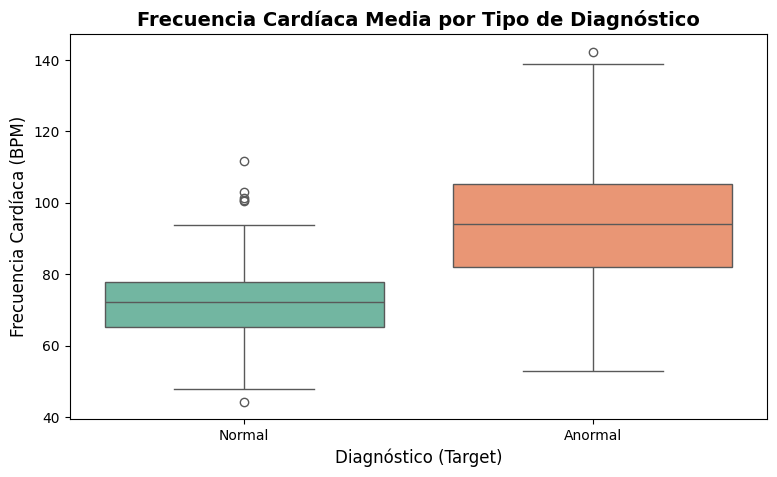

In [8]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='etiqueta', y='frecuencia_cardiaca_media_bpm', palette='Set2')
plt.title('Frecuencia Cardíaca Media por Tipo de Diagnóstico', fontsize=14, fontweight='bold')
plt.xlabel('Diagnóstico (Target)', fontsize=12)
plt.ylabel('Frecuencia Cardíaca (BPM)', fontsize=12)
plt.show()

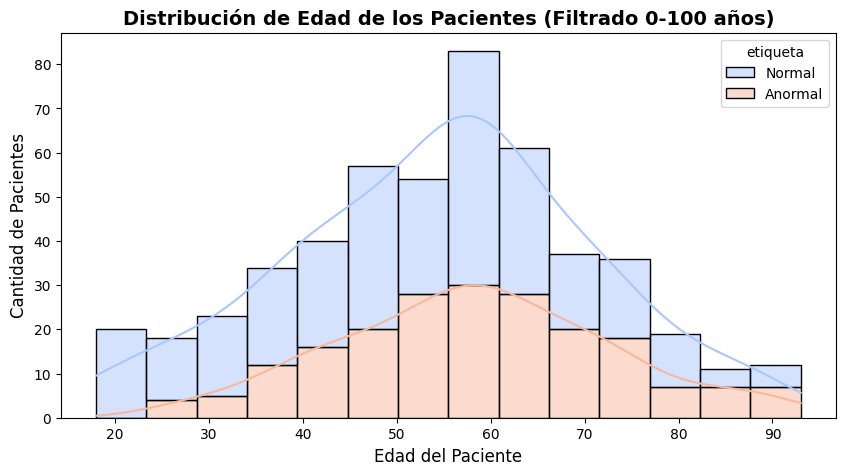

In [9]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df_filtrado, x='edad_paciente', hue='etiqueta', multiple='stack', kde=True, palette='coolwarm')
plt.title('Distribución de Edad de los Pacientes (Filtrado 0-100 años)', fontsize=14, fontweight='bold')
plt.xlabel('Edad del Paciente', fontsize=12)
plt.ylabel('Cantidad de Pacientes', fontsize=12)
plt.show()

## 5. Conclusiones y Decisiones para el Pipeline
1. **Feature Selection:** Las columnas `derivacion_ecg` y `frecuencia_muestreo_hz` se eliminarán del set de entrenamiento ya que contienen un único valor constante para todos los registros (varianza cero).
2. **Preprocesamiento:** Se requiere un paso de limpieza que transforme el string de fechas desordenado a `datetime` e impute los valores nulos detectados en Edad, Sexo, Peso y Altura.
3. **Outliers:** Las edades negativas (`-5`, `-3`) y las superiores a 130 años se tratarán mediante imputación basada en la mediana para evitar ruido en el gradiente del modelo.
4. **Insight Principal:** La frecuencia cardíaca media (`frecuencia_cardiaca_media_bpm`) es el predictor con mayor separación lineal aparente entre las clases.